# FashionCLIP wardrobe retrieval

Embed your wardrobe images with **FashionCLIP 2.0** and retrieve the most relevant items for a text query — no LLM calls, no API keys.

**How to use this notebook**
1. Run **sections 1–5** once per session (imports → model → helpers → display).
2. Edit **section 6 — Config** (`IMAGES_DIR`, `USER_QUERY`, `TOP_K`).
3. Run **Steps A–D** in order: load model → embed wardrobe → query → display.

**Setup:** `pip install transformers torch Pillow`, plus existing `pip install -r requirements.txt`.
No `.env` file required — FashionCLIP runs fully locally.

Embeddings are cached to `outputs/fashionclip_embeddings.npz` after the first run. Set `FORCE_REEMBED = True` in section 6 to rebuild the cache (e.g. after adding new images).


## 1. Imports and project paths

Run this first. Defines `ROOT` and ensures `outputs/` exists.


In [1]:
from __future__ import annotations

import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from transformers import CLIPModel, CLIPProcessor


def project_root() -> Path:
    here = Path.cwd().resolve()
    if (here / 'notebooks').is_dir() and here.name == 'notebooks':
        return here.parent
    return here


ROOT = project_root()
(ROOT / 'outputs').mkdir(parents=True, exist_ok=True)


## 2. Load FashionCLIP model and processor

Downloads `patrickjohncyh/fashion-clip` (FashionCLIP 2.0) on first run; cached locally afterwards (~600 MB).

Automatically uses Apple Silicon MPS, CUDA, or CPU — whichever is available.


In [2]:
def load_fashionclip(
    model_name: str = 'patrickjohncyh/fashion-clip',
    local_dir: Path | None = None,
) -> tuple[CLIPModel, CLIPProcessor, torch.device]:
    device = torch.device(
        'mps' if torch.backends.mps.is_available()
        else 'cuda' if torch.cuda.is_available()
        else 'cpu'
    )
    local_dir = local_dir or (ROOT / 'models' / 'fashion-clip')
    if local_dir.exists():
        print(f'Loading from local cache: {local_dir}')
        source = str(local_dir)
    else:
        print(f'Downloading {model_name!r} from HuggingFace ...')
        source = model_name
    processor = CLIPProcessor.from_pretrained(source)
    model = CLIPModel.from_pretrained(source).to(device).eval()
    if source == model_name:
        local_dir.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(str(local_dir))
        processor.save_pretrained(str(local_dir))
        print(f'Saved to {local_dir}')
    print(f'Model ready on {device}.')
    return model, processor, device


## 3. Helpers — image list, embedding, cosine similarity


In [3]:
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.gif', '.bmp'}


def list_wardrobe_images(folder: str | Path) -> list[Path]:
    folder = Path(folder).expanduser().resolve()
    if not folder.is_dir():
        raise FileNotFoundError(f'Folder not found: {folder}')
    return sorted(p for p in folder.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS)


def _image_feats(model: CLIPModel, pixel_values: torch.Tensor) -> torch.Tensor:
    # vision_model -> pooler_output -> visual_projection gives the same result
    # as get_image_features but works across all transformers versions.
    pooled = model.vision_model(pixel_values=pixel_values).pooler_output
    return model.visual_projection(pooled)


def _text_feats(model: CLIPModel, input_ids: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
    pooled = model.text_model(input_ids=input_ids, attention_mask=attention_mask).pooler_output
    return model.text_projection(pooled)


def embed_images(
    paths: list[Path],
    *,
    model: CLIPModel,
    processor: CLIPProcessor,
    device: torch.device,
    batch_size: int = 32,
) -> np.ndarray:
    # Returns L2-normalised image embeddings, shape (N, D).
    all_vecs: list[np.ndarray] = []
    for start in range(0, len(paths), batch_size):
        batch_paths = paths[start : start + batch_size]
        images = [Image.open(p).convert('RGB') for p in batch_paths]
        pixel_values = processor(images=images, return_tensors='pt')['pixel_values'].to(device)
        with torch.no_grad():
            feats = _image_feats(model, pixel_values)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        all_vecs.append(feats.cpu().float().numpy())
        print(f'  embedded {min(start + batch_size, len(paths))}/{len(paths)}')
    return np.concatenate(all_vecs, axis=0)


def embed_text(
    query: str,
    *,
    model: CLIPModel,
    processor: CLIPProcessor,
    device: torch.device,
) -> np.ndarray:
    # Returns L2-normalised text embedding, shape (1, D).
    enc = processor(text=[query], return_tensors='pt', padding=True)
    input_ids = enc['input_ids'].to(device)
    attention_mask = enc['attention_mask'].to(device)
    with torch.no_grad():
        feats = _text_feats(model, input_ids, attention_mask)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().float().numpy()


def cosine_scores(text_vec: np.ndarray, image_vecs: np.ndarray) -> np.ndarray:
    # Dot product of normalised vectors = cosine similarity. Shape: (N,).
    return (image_vecs @ text_vec.T).squeeze(-1)


## 4. Helpers — embedding cache

Saves/loads embeddings + filenames from `outputs/fashionclip_embeddings.npz`.
Set `FORCE_REEMBED = True` in section 6 to rebuild after adding new images.


In [4]:
def load_embedding_cache(
    cache_path: Path,
) -> tuple[np.ndarray, list[str]] | None:
    # Load (embeddings, filenames) from cache, or return None if missing.
    if not cache_path.is_file():
        return None
    data = np.load(cache_path, allow_pickle=False)
    embeddings = data['embeddings']          # shape (N, D)
    filenames = data['filenames'].tolist()   # list[str]
    print(f'Loaded cache: {len(filenames)} items from {cache_path}')
    return embeddings, filenames


def save_embedding_cache(
    cache_path: Path,
    embeddings: np.ndarray,
    filenames: list[str],
) -> None:
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    np.savez(cache_path, embeddings=embeddings, filenames=np.array(filenames))
    print(f'Saved cache -> {cache_path}')


def build_wardrobe_embeddings(
    images_dir: Path,
    cache_path: Path,
    *,
    model: CLIPModel,
    processor: CLIPProcessor,
    device: torch.device,
    force: bool = False,
) -> tuple[np.ndarray, list[str]]:
    # Return (embeddings, filenames). Uses cache unless force=True.
    if not force:
        cached = load_embedding_cache(cache_path)
        if cached is not None:
            return cached
    paths = list_wardrobe_images(images_dir)
    if not paths:
        raise FileNotFoundError(f'No images found in {images_dir}')
    print(f'Embedding {len(paths)} images ...')
    embeddings = embed_images(paths, model=model, processor=processor, device=device)
    filenames = [p.name for p in paths]
    save_embedding_cache(cache_path, embeddings, filenames)
    return embeddings, filenames


## 5. Helpers — query and display results

`retrieve` returns items ranked by cosine similarity. `show_results_grid` renders them with scores as titles.


In [5]:
def retrieve(
    query: str,
    embeddings: np.ndarray,
    filenames: list[str],
    *,
    model: CLIPModel,
    processor: CLIPProcessor,
    device: torch.device,
    top_k: int = 9,
) -> list[tuple[str, float]]:
    # Returns [(filename, score), ...] sorted descending by cosine similarity.
    text_vec = embed_text(query, model=model, processor=processor, device=device)
    scores = cosine_scores(text_vec, embeddings)
    top_indices = np.argsort(scores)[::-1][:top_k]
    return [(filenames[i], float(scores[i])) for i in top_indices]


def show_results_grid(
    results: list[tuple[str, float]],
    images_dir: Path,
    query: str,
    *,
    ncols: int = 4,
    thumb: int = 200,
) -> None:
    if not results:
        print('No results to display.')
        return

    n = len(results)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.4, nrows * 2.8))
    if nrows == 1 and ncols == 1:
        axes_list = [axes]
    else:
        axes_list = axes.flatten()

    for i, ax in enumerate(axes_list):
        if i < n:
            filename, score = results[i]
            p = images_dir / filename
            ax.axis('off')
            if p.is_file():
                im = Image.open(p).convert('RGB')
                im.thumbnail((thumb, thumb))
                ax.imshow(im)
            else:
                ax.text(0.5, 0.5, f'missing\n{filename}', ha='center', va='center', fontsize=9)
            ax.set_title(f'{filename}\n{score:.3f}', fontsize=8)
        else:
            ax.axis('off')

    fig.suptitle(f'Query: "{query}"', fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()


---

## 6. Config (user inputs)

Edit here, then run **Steps A–D**. Change `USER_QUERY` and re-run Steps C–D for a new search without re-embedding.


In [6]:
IMAGES_DIR = ROOT / 'images'
CACHE_PATH = ROOT / 'outputs' / 'fashionclip_embeddings.npz'

# Set True after adding new images to rebuild the embedding cache
FORCE_REEMBED = False

NCOLS = 4
THUMB = 200


### Step A — Load model


In [7]:
model, processor, device = load_fashionclip()


Loading from local cache: /Users/mohitjoshi/Projects/fashion-app/notebooks/models/fashion-clip


Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

Model ready on mps.


### Step B — Embed wardrobe (uses cache if available)


In [8]:
embeddings, filenames = build_wardrobe_embeddings(
    IMAGES_DIR,
    CACHE_PATH,
    model=model,
    processor=processor,
    device=device,
    force=FORCE_REEMBED,
)
print(f'{len(filenames)} items, embedding dim: {embeddings.shape[1]}')


Loaded cache: 23 items from /Users/mohitjoshi/Projects/fashion-app/notebooks/outputs/fashionclip_embeddings.npz
23 items, embedding dim: 512


### Step C — Query


In [11]:
USER_QUERY = 'Season: Summer, Occasion: Office Wear, dress'
TOP_K = 9

results = retrieve(
    USER_QUERY,
    embeddings,
    filenames,
    model=model,
    processor=processor,
    device=device,
    top_k=TOP_K,
)


### Step D — Display results


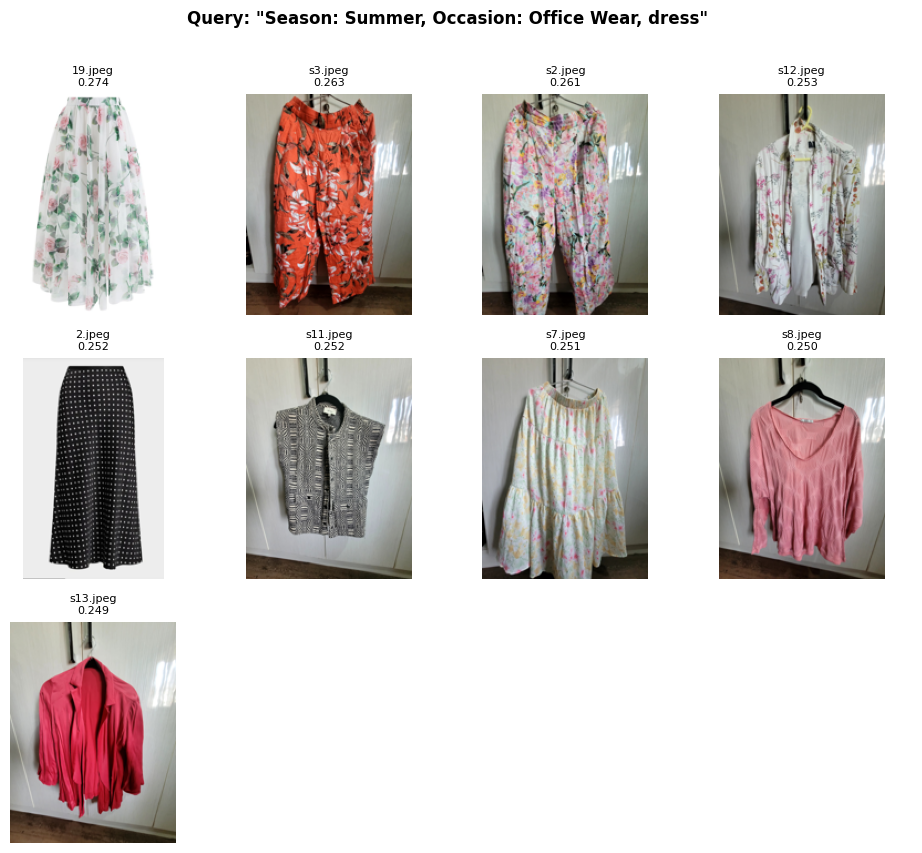

In [12]:
show_results_grid(results, IMAGES_DIR, USER_QUERY, ncols=NCOLS, thumb=THUMB)
